In [1]:
import os 
import torch
import random
import re
import warnings
import transformers
import numpy as np 
import pandas as pd
import torch.nn as nn 
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
from PIL import Image
from tqdm import tqdm
from collections import Counter
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import ViTModel, GPT2LMHeadModel, GPT2Config
from transformers import GPT2Tokenizer
import torch.nn as nn


def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything(42) 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

2026-03-26 21:23:34.688908: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774560214.870181      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774560214.920010      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


cuda


## Hyperparameters

In [2]:
seq_len = 100 
img_size = (224, 224)
embed_dim=256

## Loading Dataset

In [3]:
data_dir = '/kaggle/input/chest-xrays-indiana-university'
image_dir = f'{data_dir}/images/images_normalized'
f2 = f'{data_dir}/indiana_projections.csv'
f1 = f'{data_dir}/indiana_reports.csv'
df1 = pd.read_csv(f1)
df2 = pd.read_csv(f2)
df = pd.DataFrame({'imgs': [], 'captions': []})
for i in range(len(df2)):
    uid = df2.iloc[i]['uid']
    image = df2.iloc[i]['filename']
    index = df1.loc[df1['uid'] ==uid]
    
    if not index.empty:    
        index = index.index[0]
        caption = df1.iloc[index]['findings']
        if type(caption) == float:
         
            continue 
        df = pd.concat([df, pd.DataFrame([{'imgs': image, 'captions': caption}])], ignore_index=True)

p = '/kaggle/input/chest-xrays-indiana-university/images/images_normalized/'
df['imgs'] = p+ df['imgs']
df.head()



tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
# GPT-2 doesn’t have a pad token, so set one
tokenizer.pad_token = tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

## Preprocessing

In [4]:
def filter_captions(s):
    s=s.lower()
    s = re.sub(r"[^a-z.,]", " ", s)
    s = re.sub(r"\.+",".",s)
    s = re.sub(r"\s+", " ", s).strip()
    return s
with pd.option_context('display.max_colwidth', None):
    print(df['captions'].head())
    df['captions'] = df['captions'].apply(filter_captions)
    print(df['captions'].head())

0                                                                                                                                                                                                                                   The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no XXXX of a pleural effusion. There is no evidence of pneumothorax.
1                                                                                                                                                                                                                                   The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no XXXX of a pleural effusion. There is no evidence of pneumothorax.
2                                                                                                                         

In [5]:
def display_result(img, report, generated_report=None):
    if type(img) == str:
        img = Image.open(img)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()
    print('Report : ', report)
    if generated_report:
        print('Generated Report : ', generated_report)

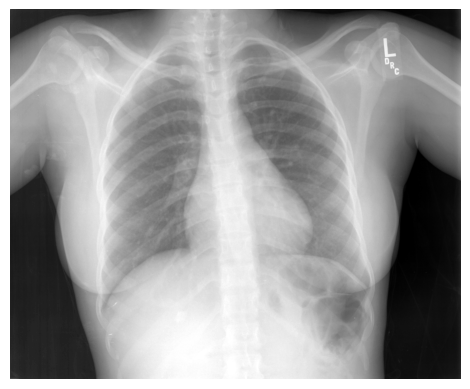

Report :  the cardiac silhouette and mediastinum size are within normal limits. there is no pulmonary edema. there is no focal consolidation. there are no xxxx of a pleural effusion. there is no evidence of pneumothorax.


In [6]:
row = df.iloc[0]
display_result(row['imgs'], row['captions'])

In [7]:


class XRayDataset(Dataset):
    def __init__(self, df, tokenizer, image_transform=None, max_length=128):
        self.image_paths = df['imgs'].tolist()
        self.captions = df['captions'].tolist()  # assume raw text captions now
        self.tokenizer = tokenizer
        self.image_transform = image_transform
        self.max_length = max_length

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Image for ViT
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.image_transform:
            image = self.image_transform(image)

        # Caption for GPT-2
        text = self.captions[idx]
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # return dict for convenience
        return {
            "pixel_values": image,  # shape [C, H, W]
            "input_ids": encoding["input_ids"].squeeze(0),  # shape [max_length]
            "attention_mask": encoding["attention_mask"].squeeze(0)  # shape [max_length]
        }


In [8]:
image_transforms = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(len(train_df), len(val_df), len(test_df))

# Now wrap in datasets
train_dataset = XRayDataset(train_df, tokenizer, image_transform=image_transforms)
val_dataset   = XRayDataset(val_df, tokenizer, image_transform=image_transforms)
test_dataset  = XRayDataset(test_df, tokenizer, image_transform=image_transforms)

# Example dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=16,num_workers=4, drop_last=True)
test_loader  = DataLoader(test_dataset, batch_size=16,num_workers=4, drop_last=True)

print(len(train_loader), len(test_loader), len(val_loader))

5175 647 647
323 40 40


In [9]:

class ViTGPT2Captioner(nn.Module):
    def __init__(self, vit_name="google/vit-base-patch16-224", gpt2_name="gpt2",  tokenizer=tokenizer):
        super().__init__()
        # Encoder
        self.vit = ViTModel.from_pretrained(vit_name)
        
        # Decoder with cross-attention
        gpt2_config = GPT2Config.from_pretrained(gpt2_name)
        gpt2_config.add_cross_attention = True
        self.gpt2 = GPT2LMHeadModel.from_pretrained(gpt2_name, config=gpt2_config)
        print(gpt2_config)
        print(self.vit)
        print(self.gpt2)
        # Optional: projection if dims mismatch
        if self.vit.config.hidden_size != gpt2_config.hidden_size:
            self.proj = nn.Linear(self.vit.config.hidden_size, gpt2_config.hidden_size)
        else:
            self.proj = None
        self.tokenizer = tokenizer

    def forward(self, pixel_values, input_ids, attention_mask=None, labels=None):
        # 1. Encode image
        vit_outputs = self.vit(pixel_values=pixel_values)
        encoder_hidden_states = vit_outputs.last_hidden_state  # [B, seq, dim]
        
        if self.proj:
            encoder_hidden_states = self.proj(encoder_hidden_states)
        
        # 2. Decode text
        outputs = self.gpt2(
            input_ids=input_ids,
            attention_mask=attention_mask,
            encoder_hidden_states=encoder_hidden_states,
            labels=labels
        )
        return outputs
    def generate(self, image, max_length=50, top_p=0.9, device="cuda"):
        self.eval()
        with torch.no_grad():
            # Encode image
            image = image.unsqueeze(0).to(device)  # [1, C, H, W]
            vit_outputs = self.vit(pixel_values=image)
            encoder_hidden_states = vit_outputs.last_hidden_state
            if self.proj:
                encoder_hidden_states = self.proj(encoder_hidden_states)

            # Start caption with <BOS> (use EOS if tokenizer has no BOS)
            caption = [self.tokenizer.bos_token_id if self.tokenizer.bos_token_id else self.tokenizer.eos_token_id]

            for _ in range(max_length):
                input_ids = torch.tensor(caption, dtype=torch.long).unsqueeze(0).to(device)

                outputs = self.gpt2(
                    input_ids=input_ids,
                    encoder_hidden_states=encoder_hidden_states
                )
                logits = outputs.logits  # [1, seq_len, vocab]
                last_logits = logits[0, -1, :]

                # Apply nucleus (top-p) sampling
                probs = torch.softmax(last_logits, dim=-1)
                sorted_probs, sorted_indices = torch.sort(probs, descending=True)
                cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

                # mask out tokens past cumulative prob threshold
                sorted_indices_to_remove = cumulative_probs > top_p
                sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                sorted_indices_to_remove[..., 0] = 0

                indices_to_remove = sorted_indices[sorted_indices_to_remove]
                probs[indices_to_remove] = 0.0
                probs = probs / torch.sum(probs)

                next_token = torch.multinomial(probs, num_samples=1).item()
                caption.append(next_token)

                if next_token == self.tokenizer.eos_token_id:
                    break

        return self.tokenizer.decode(caption, skip_special_tokens=True)
model = ViTGPT2Captioner().to(device)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Some weights of GPT2LMHeadModel were not initialized from the model checkpoint at gpt2 and are newly initialized: ['transformer.h.0.crossattention.c_attn.bias', 'transformer.h.0.crossattention.c_attn.weight', 'transformer.h.0.crossattention.c_proj.bias', 'transformer.h.0.crossattention.c_proj.weight', 'transformer.h.0.crossattention.q_attn.bias', 'transformer.h.0.crossattention.q_attn.weight', 'transformer.h.0.ln_cross_attn.bias', 'transformer.h.0.ln_cross_attn.weight', 'transformer.h.1.crossattention.c_attn.bias', 'transformer.h.1.crossattention.c_attn.weight', 'transformer.h.1.crossattention.c_proj.bias', 'transformer.h.1.crossattention.c_proj.weight', 'transformer.h.1.crossattention.q_attn.bias', 'transformer.h.1.crossattention.q_attn.weight', 'transformer.h.1.ln_cross_attn.bias', 'transformer.h.1.ln_cross_attn.weight', 'transformer.h.10.crossattention.c_attn.bias', 'transformer.h.10.crossattention.c_attn.weight', 'transformer.h.10.crossattention.c_proj.bias', 'transformer.h.10.cros

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": true,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 12,
  "n_positions": 1024,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "transformers_version": "4.52.4",
  "use_cache": true,
  "vocab_size": 50257
}

ViTModel(
  (embeddings): ViTEmbeddings(
    (patch_embeddings): ViTPatchEmbeddings(
      (projection): 

In [10]:
img_batch = next(iter(train_loader))
# print(img_batch)
caption = model.generate(img_batch['pixel_values'][0].to(device))

In [11]:
print(caption)

Bang!

"They said, 'Hey, you know, we have a problem with this guy', but it was her fault, so we knew there wasn't a problem at all!" Qian Qian instantly felt a high level of guilt!



In [12]:
def validate_model(model, val_loader, device):
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch["pixel_values"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=input_ids
            )

            val_loss += outputs.loss.item()

    avg_val_loss = val_loss / len(val_loader)
    return avg_val_loss


def generate_caption_sanity_check(model, val_dataset, tokenizer, device, idx=0, max_new_tokens=100):
    model.eval()
    idx = random.randint(0, len(val_dataset) - 1)
    sample = val_dataset[idx]
    pixel_values = sample["pixel_values"].to(device)

    with torch.no_grad():
        generated_caption = model.generate(
            image=pixel_values,
            max_length=max_new_tokens,
            device=device
        )

    reference_caption = tokenizer.decode(sample["input_ids"], skip_special_tokens=True)

    print(f"\n--- Sanity Check ---")
    print(f"Reference: {reference_caption}")
    print(f"Generated: {generated_caption}")
    print("-------------------\n")

def train_model(model, train_loader, val_loader, val_dataset, tokenizer, device, epochs=5, lr=5e-5, log_steps=20, save_dir="checkpoints"):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    best_val_loss = float("inf")  # initialize best loss
    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for step, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1} Training")):
            pixel_values = batch["pixel_values"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            optimizer.zero_grad()

            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=input_ids
            )

            loss = outputs.loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            if (step + 1) % log_steps == 0:
                avg_loss = total_loss / (step + 1)
                print(f"Epoch {epoch+1} | Step {step+1}/{len(train_loader)} | Loss: {avg_loss:.4f}")

        avg_train_loss = total_loss / len(train_loader)

        # run validation
        avg_val_loss = validate_model(model, val_loader, device)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # check if this is the best model so far
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            save_path = os.path.join(save_dir, f"best_model_epoch{epoch+1}.pt")
            torch.save(model.state_dict(), save_path)
            print(f"✅ Saved new best model at {save_path} with Val Loss: {avg_val_loss:.4f}")

        # sanity check
        generate_caption_sanity_check(model, val_dataset, tokenizer, device)




In [13]:
from torch.utils.data import Subset
# mock_train_dataset = Subset(train_dataset, list(range(48)))
# mock_val_dataset = Subset(val_dataset, list(range(112)))

# mock_train_loader = DataLoader(mock_train_dataset, batch_size=8, shuffle=True)
# mock_val_loader = DataLoader(mock_val_dataset, batch_size=8, shuffle=False)
# (model, train_loader, val_loader, val_dataset, tokenizer, device, epochs=5, lr=5e-5, log_steps=20)
train_model(model, train_loader, val_loader, val_dataset,tokenizer, device)

Epoch 1 Training:   6%|▌         | 20/323 [00:26<05:55,  1.17s/it]

Epoch 1 | Step 20/323 | Loss: 2.3439


Epoch 1 Training:  12%|█▏        | 40/323 [00:50<05:44,  1.22s/it]

Epoch 1 | Step 40/323 | Loss: 1.7845


Epoch 1 Training:  19%|█▊        | 60/323 [01:15<05:29,  1.25s/it]

...

Epoch 5 | Step 300/323 | Loss: 0.3771


Epoch 5 Training:  99%|█████████▉| 320/323 [07:03<00:03,  1.32s/it]

Epoch 5 | Step 320/323 | Loss: 0.3757


Epoch 5 Training: 100%|██████████| 323/323 [07:07<00:00,  1.32s/it]


Epoch 5/5 | Train Loss: 0.3759 | Val Loss: 0.3348
✅ Saved new best model at checkpoints/best_model_epoch5.pt with Val Loss: 0.3348

--- Sanity Check ---
Reference: the lungs are clear bilaterally. specifically, no evidence of focal consolidation, pneumothorax, or pleural effusion. cardio mediastinal silhouette is unremarkable. visualized osseous structures of the thorax are without acute abnormality.
Generated: c xxxx sternotomy xxxx with intact postoperative scoliosis, unchanged bibasilar xxxx sternotomy and lateral views of the chest from prior cabg. the cardiomediastinal silhouette is within normal limits. the lungs are clear without focal consolidation, pneumothorax or large pleural effusion. multilevel degenerative changes of the thoracic spine.
-------------------



In [14]:
# embed_dim = 256
# ff_dim = 512
# num_heads = 4
# num_decoder_layers = 2
# vocab_size = tokenizer.vocab_size
# max_len = 102

# cnn_encoder = ImageEncoder(embed_dim=embed_dim)
# transformer_encoder = TransformerEncoderBlock(embed_dim=embed_dim, num_heads= num_heads, ff_dim=ff_dim)
# decoder = CaptionDecoder(vocab_size, embed_dim,ff_dim, num_heads,max_len, num_layers)

# model = ImageCaptioningModel(cnn_encoder, transformer_encoder, decoder, tokenizer).to(device)


## Training

In [15]:
torch.save(model.state_dict(), "vit-gpt_model.pt")

In [16]:
%%capture
model = ViTGPT2Captioner().to(device)
model.load_state_dict(torch.load("vit-gpt_model.pt"))
model.eval()

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of GPT2LMHeadModel were not initialized from the model checkpoint at gpt2 and are newly initialized: ['transformer.h.0.crossattention.c_attn.bias', 'transformer.h.0.crossattention.c_attn.weight', 'transformer.h.0.crossattention.c_proj.bias', 'transformer.h.0.crossattention.c_proj.weight', 'transformer.h.0.crossattention.q_attn.bias', 'transformer.h.0.crossattention.q_attn.weight', 'transformer.h.0.ln_cross_attn.bias', 'transformer.h.0.ln_cross_attn.weight', 'transformer.h.1.crossattention.c_attn.bias', 'transformer.h.1.crossattention.c_attn.weight', 'transformer.h.1.crossattention.c_proj.bias', 'transformer.h.1.crossattention.c_proj.weight', 'transformer.h.1.crossattention.q_attn.bias', 'tran

In [17]:
%%capture
!pip install nltk bert-score rouge-score
!pip install rouge_score
!pip install bert_score

In [18]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


True

In [19]:
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
import bert_score

def evaluate_metrics(model, val_dataset, tokenizer, device, num_samples=200):
    model.eval()
    references = []
    hypotheses = []

    with torch.no_grad():
        for i in tqdm(range(min(num_samples, len(val_dataset)))):
            sample = val_dataset[i]
            pixel_values = sample["pixel_values"].to(device)
            input_ids = sample["input_ids"]

            # reference text
            ref_text = tokenizer.decode(input_ids, skip_special_tokens=True)
            references.append([ref_text.split()])  # corpus_bleu expects list of lists of tokens

            # generate prediction
            pred_text = model.generate(pixel_values, max_length=64)
            hypotheses.append(pred_text.split())

    # BLEU
    bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0))
    bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25))

    # METEOR (requires single refs)
    meteor = sum([
        meteor_score([ref[0]], hyp)  # both ref[0] and hyp are already tokenized lists
        for ref, hyp in zip(references, hypotheses)
        ]) / len(hypotheses)

    # ROUGE
    rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    rouge_scores = [rouge.score(" ".join(ref[0]), " ".join(hyp)) 
                    for ref, hyp in zip(references, hypotheses)]
    rougeL = sum([s['rougeL'].fmeasure for s in rouge_scores]) / len(rouge_scores)

    # BERTScore
    preds = [" ".join(hyp) for hyp in hypotheses]
    refs = [" ".join(ref[0]) for ref in references]
    P, R, F1 = bert_score.score(preds, refs, lang="en", verbose=False)

    return {
        "BLEU-1": bleu1,
        "BLEU-4": bleu4,
        "METEOR": meteor,
        "ROUGE-L": rougeL,
        "BERTScore-F1": F1.mean().item(),
        "BERTScore Precision": P.mean().item(),
        "BERTScore Recall":R.mean().item()

    }
metrics = evaluate_metrics(model, val_dataset, tokenizer, device)
print("Evaluation Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")


100%|██████████| 200/200 [02:39<00:00,  1.25it/s]


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Evaluation Metrics:
BLEU-1: 0.2751
BLEU-4: 0.0560
METEOR: 0.2170
ROUGE-L: 0.2444
BERTScore-F1: 0.8760
BERTScore Precision: 0.8751
BERTScore Recall: 0.8774


In [20]:
# # Assuming 'model' is your trained model and it's on the 'device'
# # Set the device
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# model.to(device)

# # Run the evaluation
# test_metrics = evaluate_model(model, test_loader, tokenizer, device)

# # Print the final results in a clean format
# print("\n--- Test Set Evaluation Metrics ---")
# for metric, value in test_metrics.items():
#     print(f"{metric.upper():<12}: {value:.4f}")

In [21]:
import textwrap

def visualize_result(img_path, true_report, generated_report, title="Model Prediction"):

    img = Image.open(img_path).convert("RGB")
    
    plt.figure(figsize=(12, 6))
    plt.imshow(img, cmap="gray")
    plt.axis('off')
    
    wrapped_true = textwrap.fill(f"Ground Truth: {true_report}", width=100)
    wrapped_gen = textwrap.fill(f"Generated: {generated_report}", width=100)
    
    plt.title(title, fontsize=14, pad=20)
    plt.figtext(0.5, 0.01, f"{wrapped_true}\n\n{wrapped_gen}", 
                ha="center", va="bottom", fontsize=12, wrap=True, bbox={"facecolor":"white", "alpha":0.7, "pad":5})
    
    plt.show()



In [22]:
def show_random_test_examples(model, test_df, tokenizer, image_transforms, device, num_examples=3):

    model.eval()
    
    random_indices = random.sample(range(len(test_df)), num_examples)
    
    for i, idx in enumerate(random_indices):
        sample_row = test_df.iloc[idx]
        img_path = sample_row['imgs']
        true_report = sample_row['captions']
        
        image_pil = Image.open(img_path).convert("RGB")
        image_tensor = image_transforms(image_pil).unsqueeze(0).to(device)
        
        print(f"--- Example {i+1}/{num_examples} ---")
        
        with torch.no_grad():
            generated_report = model.generate(image_tensor.squeeze(0), max_length=102, device=device)
        visualize_result(img_path, true_report, generated_report, title=f"Test Example {i+1}")

--- Example 1/10 ---


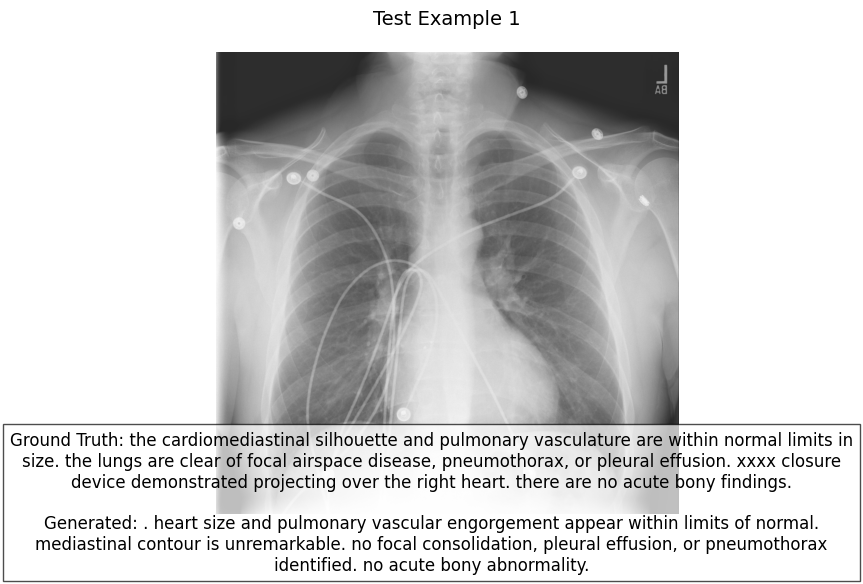

--- Example 2/10 ---


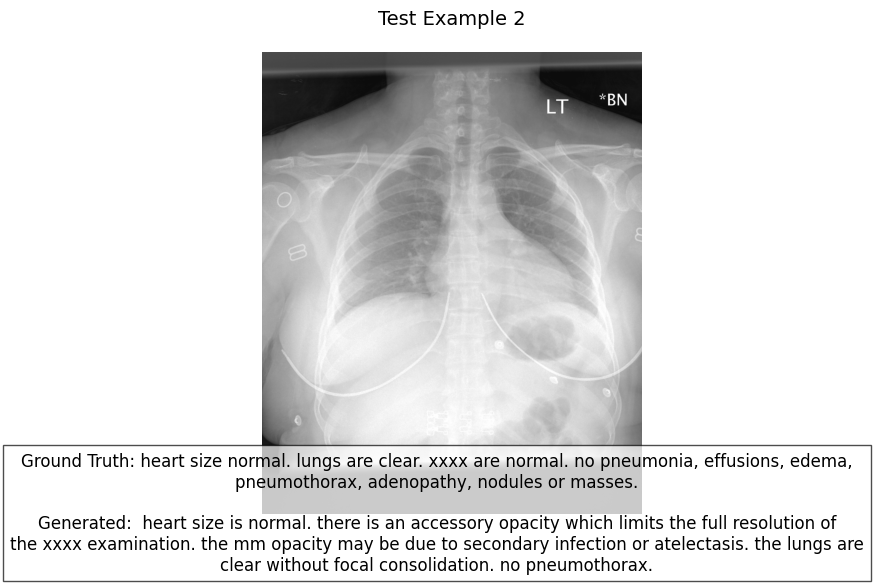

--- Example 3/10 ---


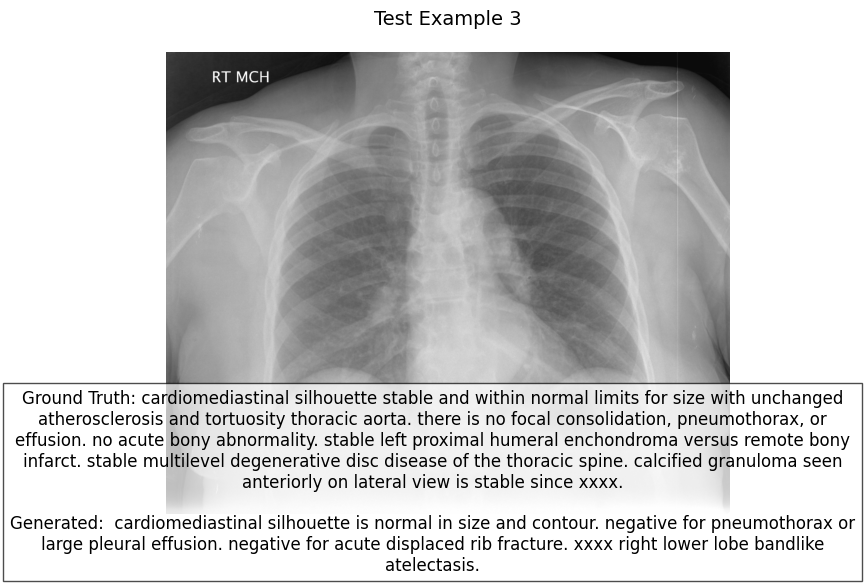

--- Example 4/10 ---


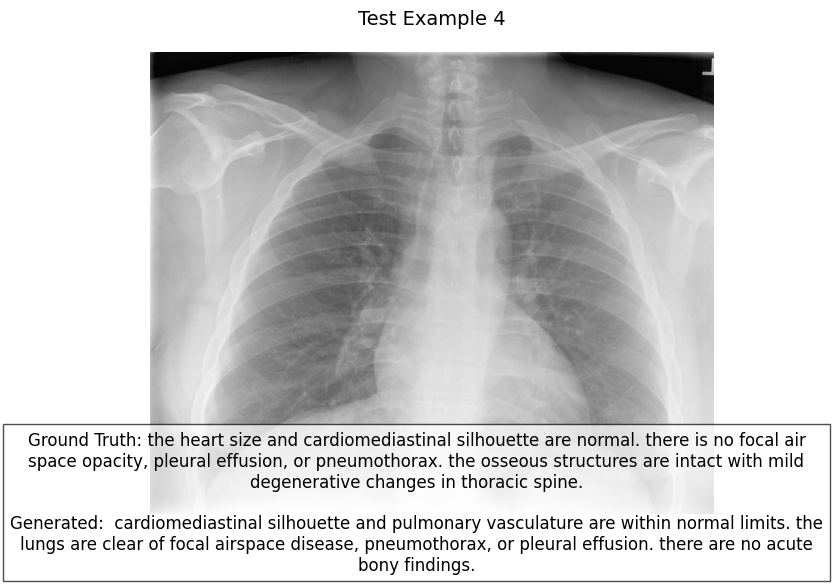

--- Example 5/10 ---


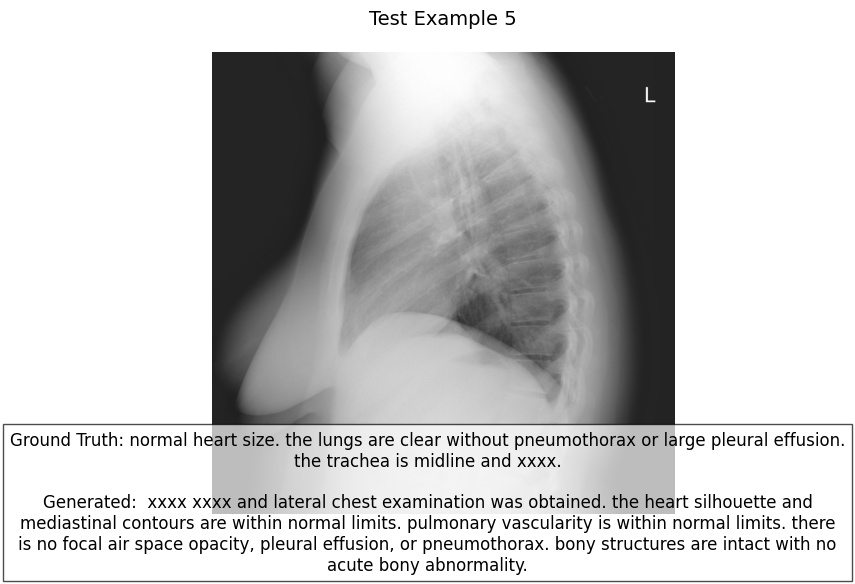

--- Example 6/10 ---


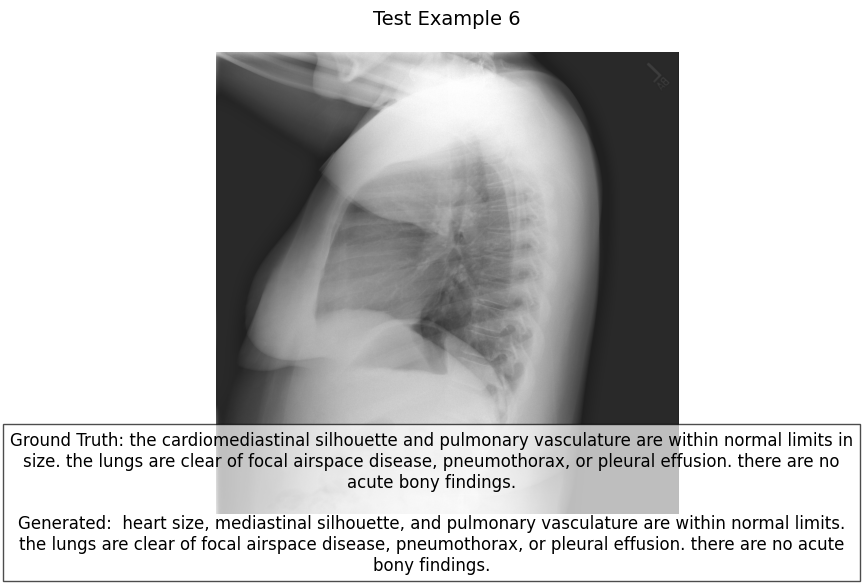

--- Example 7/10 ---


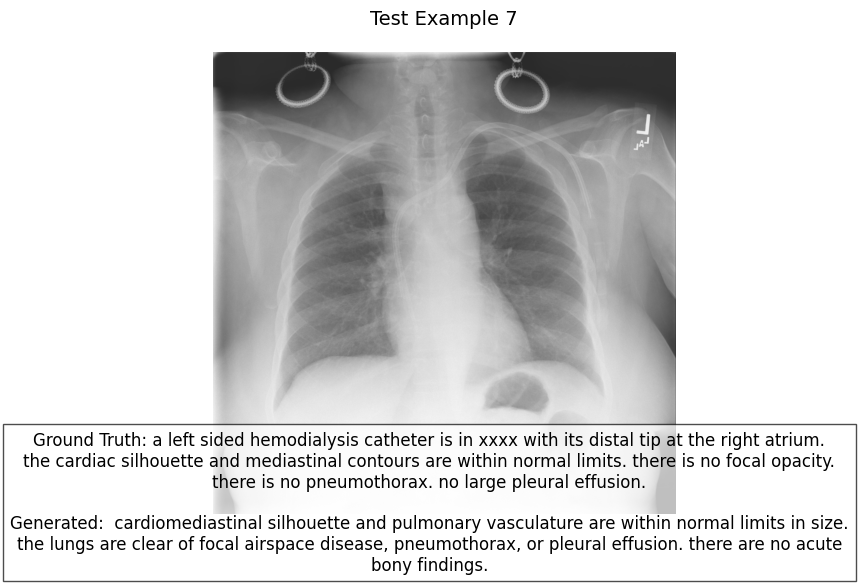

--- Example 8/10 ---


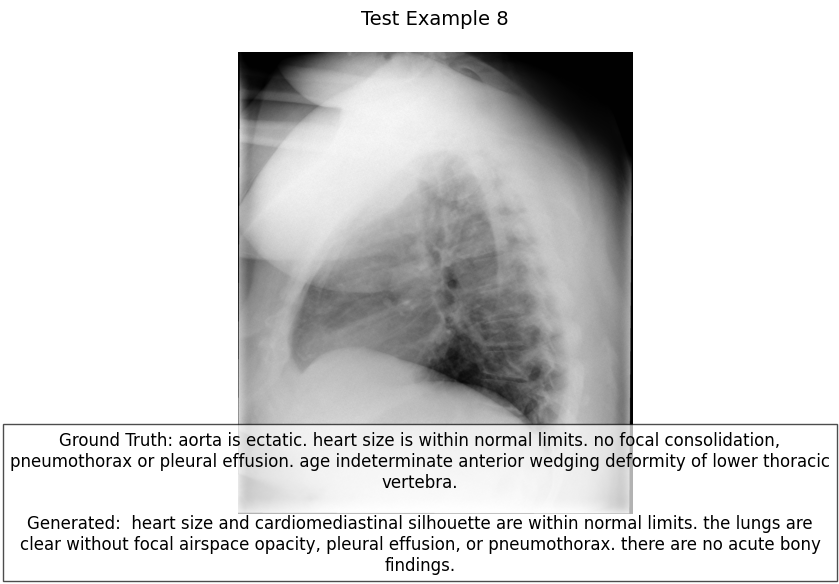

--- Example 9/10 ---


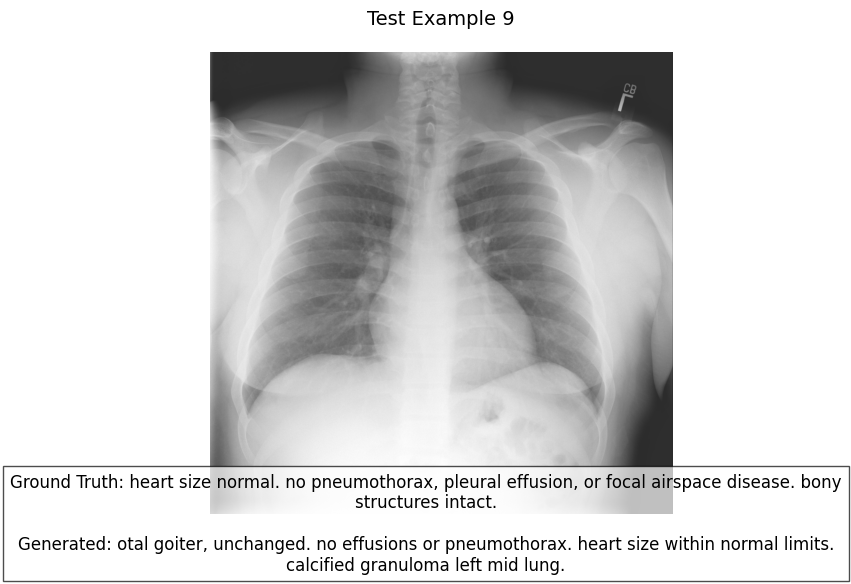

--- Example 10/10 ---


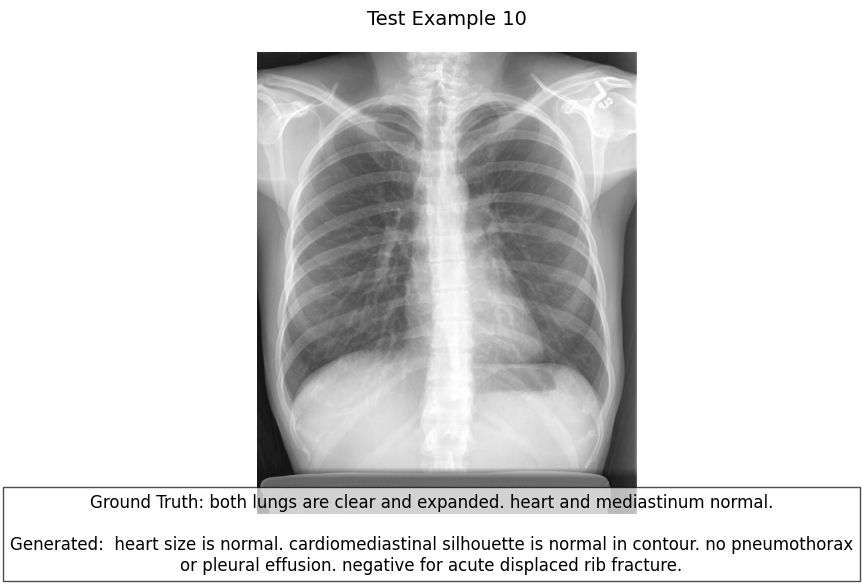

In [23]:


device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

# Call the function to show 5 random examples
show_random_test_examples(model, test_df, tokenizer, image_transforms, device, num_examples=10)



In [24]:
save_path = "multimodal_model.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": epoch,
    "train_loss": avg_train_loss,
    "val_loss": avg_val_loss
}, save_path)

print(f"Model saved to {save_path}")

NameError: name 'optimizer' is not defined